<a href="https://colab.research.google.com/github/YashviGupta15/ai-ml-notes/blob/main/LSTM_Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Section 1: From TF-IDF to Sequence Models

## Why are we moving beyond TF-IDF?

In the previous lecture, we built a sentiment analysis pipeline using **TF-IDF + classical machine learning**.

That approach worked well because it converted each document into a fixed-length feature vector:

$$
\mathbf{x} \in \mathbb{R}^V
$$

where $V$ is the vocabulary size.

Each component measured the importance of a word in a document relative to the corpus.
This is powerful for many classification tasks.

But today we ask a deeper question:

> Does a document mean only **which words appear**, or also **the order in which they appear**?

## What TF-IDF captures well

TF-IDF is useful when:

- word importance matters
- document-level classification is the main goal
- order is less critical
- we want interpretable sparse features

For example, in sentiment classification:

- "excellent", "amazing", "worst", "poor"  
can already provide strong signal.

So TF-IDF is not "wrong" — it is simply **limited**.

## What TF-IDF misses

TF-IDF treats text mostly as a **bag of weighted words**.

So these two sentences become very similar:

1. **"not good"**
2. **"good"**

and these may also look close:

1. **"dog bites man"**
2. **"man bites dog"**

But meaning changes when order changes.

TF-IDF does not naturally model:

- word order
- local context
- evolving meaning across positions
- dependence of later words on earlier words

## Static representation vs dynamic representation

In TF-IDF, the whole sentence or document is compressed into one fixed vector:

$$
\mathbf{x}_{\text{doc}} = [x_1, x_2, \dots, x_V]
$$

This is a **static representation**.

In sequence models, we process tokens one step at a time:

$$
x_1, x_2, x_3, \dots, x_T
$$

and build an internal evolving representation:

$$
h_t = f(x_t, h_{t-1})
$$

So meaning is no longer treated as one frozen vector.
Instead, meaning is **updated through time** as the sequence unfolds.

## Example intuition

Consider the sentence:

> "I thought the movie would be great, but it was disappointing."

If we only count important words, both "great" and "disappointing" appear.

But the actual sentiment depends on how meaning develops across the sequence.

A sequence model can read:

- first: expectation is positive
- later: reversal happens with "but"
- final interpretation becomes negative

So in sequence modeling, meaning is not just present in words —
it is present in the **trajectory of words**.

## Why this matters for deep learning NLP

Many NLP tasks require order-sensitive understanding:

- next word prediction
- machine translation
- text generation
- speech / sequence labeling
- question answering
- summarization

These tasks require a model to remember what came before and use it while processing what comes next.

That is the motivation for recurrent sequence models.

## Bridge to recurrent models

So the transition is:

- **TF-IDF**: useful for document-level signals, but ignores sequence structure
- **Sequence models**: process text token by token and maintain evolving context

Vanilla RNN was one of the earliest deep learning solutions for this idea:

$$
h_t = \tanh(W_x x_t + W_h h_{t-1} + b)
$$

We already know this update rule.

Now the key question becomes:

> If RNN carries information forward through $h_t$, why does it still struggle on long sequences?

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

sentences = [
    "good movie",
    "not good movie",
    "man bites dog",
    "dog bites man"
]

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(sentences)

df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out(), index=sentences)
df

,bites,dog,good,man,movie,not
good movie,0.00000,0.00000,0.707107,0.00000,0.707107,0.000000
not good movie,0.00000,0.00000,0.526405,0.00000,0.526405,0.667679
man bites dog,0.57735,0.57735,0.000000,0.57735,0.000000,0.000000
dog bites man,0.57735,0.57735,0.000000,0.57735,0.000000,0.000000


In [ ]:
print("Vocabulary:", vectorizer.get_feature_names_out())
print("\nTF-IDF shape:", X.shape)

Vocabulary: ['bites' 'dog' 'good' 'man' 'movie' 'not']

TF-IDF shape: (4, 6)


In [ ]:
for s in sentences:
    print(f"{s}  -->  {s.split()}")

good movie  -->  ['good', 'movie']
not good movie  -->  ['not', 'good', 'movie']
man bites dog  -->  ['man', 'bites', 'dog']
dog bites man  -->  ['dog', 'bites', 'man']


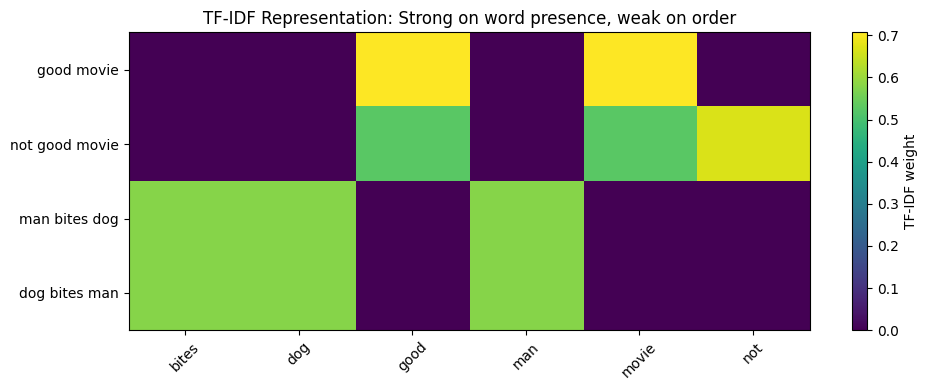

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 4))
plt.imshow(df.values, aspect='auto')
plt.xticks(np.arange(len(df.columns)), df.columns, rotation=45)
plt.yticks(np.arange(len(df.index)), df.index)
plt.colorbar(label="TF-IDF weight")
plt.title("TF-IDF Representation: Strong on word presence, weak on order")
plt.tight_layout()
plt.show()

### Concept Check

1. Why is TF-IDF called a static representation?

2. Give one NLP task where TF-IDF can work reasonably well.

3. Give one NLP task where TF-IDF is fundamentally limited.

4. Why are "good movie" and "not good movie" a useful comparison?

5. What is the main conceptual difference between:
   - document vector representation
   - sequence state representation

6. In one line, why do we need sequence models?

We now have the motivation for sequence modeling.

But a natural question remains:

If vanilla RNN already processes tokens one by one and carries a hidden state forward,  
why is that still not enough for long sequences?

To answer that, we next study the core weakness of vanilla RNN:
**long-term dependency failure and vanishing gradients.**

# Section 2: Why Vanilla RNN Fails on Long Dependencies

We already know the vanilla RNN hidden state update:

$$
h_t = \tanh(W_x x_t + W_h h_{t-1} + b)
$$

This looks reasonable:

- current state depends on current input
- current state also depends on previous hidden state

So in principle, information from the past can flow forward.

But in practice, vanilla RNN struggles when useful information must be preserved for many time steps.

## What is a long-term dependency?

A long-term dependency occurs when prediction at time $t$ depends on information that appeared much earlier.

Example:

> "I grew up in France ... I speak fluent ____"

To predict the missing word, the model may need to remember **France** across many intermediate words.

If the signal from the distant past fades away, the model cannot use it effectively.

So the core question is:

> Can the RNN really preserve relevant information over long distances?

## Forward view: repeated state transformation

If we expand the recurrence conceptually, each hidden state is built from repeated transformations:

$$
h_t \leftarrow h_{t-1} \leftarrow h_{t-2} \leftarrow \cdots \leftarrow h_1
$$

So old information is repeatedly passed through:

- matrix multiplication by $W_h$
- nonlinearity $\tanh(\cdot)$

This repeated transformation can gradually distort, shrink, or sometimes amplify signals.

## Backward view: gradients must also travel through time

During training, the loss at a later time step must send learning signal backward to earlier states.

If the total loss is

$$
L = \sum_{t=1}^{T} L_t
$$

then parameters influencing early time steps are updated through gradients that pass through many recurrent connections.

For example, if a loss at time $T$ depends on $h_T$, and $h_T$ depends on $h_{T-1}$, which depends on $h_{T-2}$, and so on, then:

$$
\frac{\partial L_T}{\partial h_k}
=
\frac{\partial L_T}{\partial h_T}
\frac{\partial h_T}{\partial h_{T-1}}
\frac{\partial h_{T-1}}{\partial h_{T-2}}
\cdots
\frac{\partial h_{k+1}}{\partial h_k}
$$

This is the chain rule through time.

## Local Jacobian of the recurrent step

Let

$$
a_t = W_x x_t + W_h h_{t-1} + b
$$

and

$$
h_t = \tanh(a_t)
$$

Then the derivative of $h_t$ with respect to $h_{t-1}$ is:

$$
\frac{\partial h_t}{\partial h_{t-1}}
=
\operatorname{diag}\left(1 - \tanh^2(a_t)\right) W_h
$$

So the backpropagated gradient is repeatedly multiplied by terms of the form:

$$
\operatorname{diag}\left(1 - \tanh^2(a_t)\right) W_h
$$

over many time steps.

## Why gradients vanish

Notice that for $\tanh(z)$:

$$
\frac{d}{dz}\tanh(z) = 1 - \tanh^2(z)
$$

and this derivative always lies in the interval:

$$
0 < 1 - \tanh^2(z) \leq 1
$$

When $\tanh(z)$ is saturated near $-1$ or $1$, the derivative becomes very small.

So if we repeatedly multiply many small factors, the overall gradient shrinks rapidly:

$$
\left\|
\frac{\partial L_T}{\partial h_k}
\right\|
\approx
\prod_{j=k+1}^{T}
\left\|
\frac{\partial h_j}{\partial h_{j-1}}
\right\|
\to 0
\quad \text{as } T-k \text{ grows}
$$

This is the **vanishing gradient problem**.

## Why gradients can also explode

The repeated product does not always shrink.

If the effective norm of the recurrent Jacobian is greater than $1$, then repeated multiplication can make gradients grow very large:

$$
\prod_{j=k+1}^{T}
\left\|
\frac{\partial h_j}{\partial h_{j-1}}
\right\|
\to \infty
$$

This is the **exploding gradient problem**.

So vanilla RNN training suffers from two opposite risks:

- gradients become too small to learn long-range dependence
- gradients become too large and destabilize training

## Role of $\tanh$ saturation

The problem is not only the matrix $W_h$.

The nonlinearity also matters.

For large positive or negative inputs:

$$
\tanh(z) \approx 1 \quad \text{or} \quad \tanh(z) \approx -1
$$

and then:

$$
1 - \tanh^2(z) \approx 0
$$

That means the neuron output changes very little even if the input changes.

So in saturated regions:

- forward information becomes compressed
- backward gradients become weak

This makes it difficult for the model to preserve or learn long-term effects.

## Interpretation: memory is fragile in vanilla RNN

Vanilla RNN does have memory, but it is an **unstable memory**.

Why?

Because remembered information must survive repeated nonlinear transformation.

There is no explicit mechanism saying:

- keep this information
- forget that information
- protect this signal from being overwritten

Everything is mixed into the same hidden state update.

## Core takeaway

Vanilla RNN is elegant, but for long sequences it has a structural weakness:

- information must pass through many recurrent steps
- gradients must also pass through those same steps
- repeated multiplication causes shrinking or amplification
- $\tanh$ saturation makes long-range learning even harder

So we need a recurrence mechanism with **better gradient flow** and **more controlled memory**.

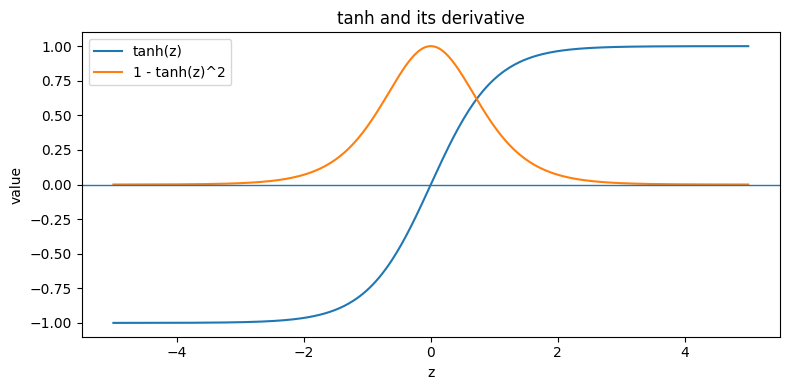

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

z = np.linspace(-5, 5, 400)
tanh_z = np.tanh(z)
tanh_derivative = 1 - tanh_z**2

plt.figure(figsize=(8, 4))
plt.plot(z, tanh_z, label='tanh(z)')
plt.plot(z, tanh_derivative, label="1 - tanh(z)^2")
plt.axhline(0, linewidth=1)
plt.title("tanh and its derivative")
plt.xlabel("z")
plt.ylabel("value")
plt.legend()
plt.tight_layout()
plt.show()

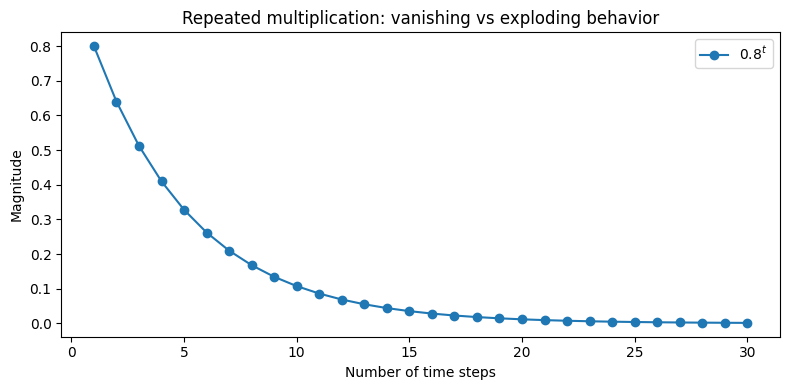

In [ ]:
small_factor = 0.8
large_factor = 1.2

steps = np.arange(1, 31)
vanishing = small_factor ** steps
exploding = large_factor ** steps

plt.figure(figsize=(8, 4))
plt.plot(steps, vanishing, marker='o', label=r"$0.8^t$")
#plt.plot(steps, exploding, marker='o', label=r"$1.2^t$")
plt.title("Repeated multiplication: vanishing vs exploding behavior")
plt.xlabel("Number of time steps")
plt.ylabel("Magnitude")
plt.legend()
plt.tight_layout()
plt.show()

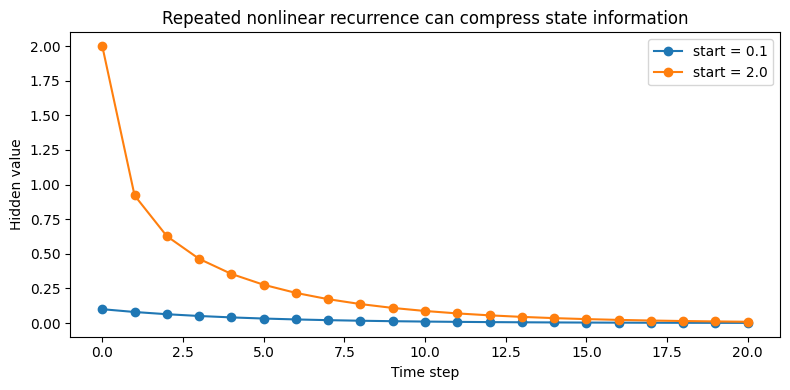

In [ ]:
# A small toy recurrence to show how repeated transformation can wash out differences

def run_recurrence(h0, steps=20, w=0.8):
    hs = [h0]
    h = h0
    for _ in range(steps):
        h = np.tanh(w * h)
        hs.append(h)
    return np.array(hs)

steps = 20
h_a = run_recurrence(0.1, steps=steps, w=0.8)
h_b = run_recurrence(2.0, steps=steps, w=0.8)

plt.figure(figsize=(8, 4))
plt.plot(range(steps + 1), h_a, marker='o', label='start = 0.1')
plt.plot(range(steps + 1), h_b, marker='o', label='start = 2.0')
plt.title("Repeated nonlinear recurrence can compress state information")
plt.xlabel("Time step")
plt.ylabel("Hidden value")
plt.legend()
plt.tight_layout()
plt.show()

### Concept Check

1. What do we mean by a long-term dependency in sequence modeling?

2. Why does the gradient from a late loss have to pass through many time steps?

3. In one line, why can repeated multiplication cause vanishing gradients?

4. What is the derivative of $\tanh(z)$?

5. Why does $\tanh$ saturation worsen the vanishing gradient problem?

6. Can vanilla RNN suffer only from vanishing gradients, or also exploding gradients?

7. What is the deeper issue here:
   - lack of expressive power only
   - or difficulty of optimization through time?

We now understand the central weakness of vanilla RNN:

- memory must survive repeated nonlinear updates
- gradients must survive repeated Jacobian multiplication

So the next question is natural:

> Can we design a recurrent model where memory has a more protected path, and the model can decide what to keep, what to forget, and what to expose?

That leads us to **LSTM**.

# Section 3: LSTM as a Solution to Fragile Memory

Vanilla RNN stores everything inside a single hidden state:

$$
h_t = \tanh(W_x x_t + W_h h_{t-1} + b)
$$

This creates two problems:

- memory is repeatedly overwritten
- gradients must pass through repeated nonlinear transformations

LSTM introduces a more controlled memory mechanism.

The key idea is:

> Do not store everything in one place.  
> Separate **internal memory** from **visible state**, and control information flow using gates.

## Two states in LSTM

At each time step, LSTM maintains two different vectors:

- **cell state**: $c_t$
- **hidden state**: $h_t$

### Intuition

- $c_t$ is the long-term memory channel
- $h_t$ is the exposed working state used for output and interaction with the next step

So unlike vanilla RNN, LSTM does not force all information into one hidden vector.
It creates a more structured memory system.

## Why gating is needed

At every step, the model must answer questions like:

- What old information should be kept?
- What old information should be erased?
- What new information should be written?
- What part of memory should be revealed as output?

LSTM answers these questions using gates.

A gate is typically a sigmoid-based controller:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

Since

$$
0 < \sigma(z) < 1
$$

a gate can scale information continuously:

- near $0$: block it
- near $1$: pass it

## Step 1: Forget gate

The forget gate decides how much of the previous cell state should be retained.

$$
f_t = \sigma(W_f x_t + U_f h_{t-1} + b_f)
$$

Here:

- $x_t$ = current input
- $h_{t-1}$ = previous hidden state
- $f_t$ = forget gate vector

Interpretation:

- if a component of $f_t$ is close to $1$, keep that memory
- if a component is close to $0$, forget that memory

## Step 2: Input gate

The input gate decides how much new information should be written into memory.

$$
i_t = \sigma(W_i x_t + U_i h_{t-1} + b_i)
$$

This does not create content by itself.

It only decides:

> How strongly should the new candidate memory be allowed to enter?

## Step 3: Candidate memory

The model also computes a candidate memory content:

$$
\tilde{c}_t = \tanh(W_c x_t + U_c h_{t-1} + b_c)
$$

This is the new information proposal.

Interpretation:

- $i_t$ decides **how much to write**
- $\tilde{c}_t$ decides **what to write**

## Step 4: Cell state update

Now we combine retained old memory and gated new memory:

$$
c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t
$$

where $\odot$ denotes elementwise multiplication.

This is the most important LSTM equation.

It says:

- keep part of old memory: $f_t \odot c_{t-1}$
- add selected new memory: $i_t \odot \tilde{c}_t$

So memory is updated **additively**, not only through full nonlinear replacement.

## Why the additive update matters

In vanilla RNN, hidden state is repeatedly transformed through:

$$
h_t = \tanh(\cdots)
$$

So information is always pushed through a nonlinearity.

In LSTM, the cell state update contains a direct additive path:

$$
c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t
$$

This is important because the derivative of $c_t$ with respect to $c_{t-1}$ is approximately:

$$
\frac{\partial c_t}{\partial c_{t-1}} = f_t
$$

elementwise.

So if $f_t$ is near $1$, memory — and gradient — can pass through many steps much more easily.

This is the core reason LSTM improves long-range learning.

## Step 5: Output gate

Not all internal memory should be exposed at every step.

So LSTM uses an output gate:

$$
o_t = \sigma(W_o x_t + U_o h_{t-1} + b_o)
$$

This gate decides which part of the internal memory becomes visible in the hidden state.

## Step 6: Hidden state update

The hidden state is computed as:

$$
h_t = o_t \odot \tanh(c_t)
$$

Interpretation:

- $c_t$ is the internal memory
- $\tanh(c_t)$ gives a squashed version of memory
- $o_t$ decides how much of that memory is exposed

So:

- $c_t$ stores
- $h_t$ reveals

## Full LSTM equations together

The standard LSTM equations are:

$$
f_t = \sigma(W_f x_t + U_f h_{t-1} + b_f)
$$

$$
i_t = \sigma(W_i x_t + U_i h_{t-1} + b_i)
$$

$$
\tilde{c}_t = \tanh(W_c x_t + U_c h_{t-1} + b_c)
$$

$$
c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t
$$

$$
o_t = \sigma(W_o x_t + U_o h_{t-1} + b_o)
$$

$$
h_t = o_t \odot \tanh(c_t)
$$

## Cell state vs hidden state

### Cell state $c_t$
- internal memory channel
- designed for long-term information flow
- updated additively
- more protected from repeated distortion

### Hidden state $h_t$
- visible state passed to output layers
- also passed forward to help gate computation
- acts more like the current working representation

A useful mental model:

- $c_t$ = memory bank
- $h_t$ = what the model chooses to say right now

## Why LSTM is better than vanilla RNN

LSTM improves recurrence in two major ways:

1. **Controlled memory update**
   - not everything is overwritten at every step

2. **Improved gradient flow**
   - additive memory path reduces severe vanishing

This does not make LSTM perfect,
but it makes learning long dependencies far more practical.

## Important limitation

LSTM helps with long-range dependencies,
but it still processes sequence information step by step.

So later we will still ask:

- can recurrence parallelize efficiently?
- can it access distant tokens more directly?
- does fixed-size state remain a bottleneck?

Those questions will motivate the next lecture.

In [ ]:
import numpy as np

np.random.seed(42)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Small illustrative dimensions
input_dim = 3
hidden_dim = 4

x_t = np.random.randn(input_dim, 1)
h_prev = np.random.randn(hidden_dim, 1)
c_prev = np.random.randn(hidden_dim, 1)

W_f = np.random.randn(hidden_dim, input_dim)
U_f = np.random.randn(hidden_dim, hidden_dim)
b_f = np.random.randn(hidden_dim, 1)

W_i = np.random.randn(hidden_dim, input_dim)
U_i = np.random.randn(hidden_dim, hidden_dim)
b_i = np.random.randn(hidden_dim, 1)

W_c = np.random.randn(hidden_dim, input_dim)
U_c = np.random.randn(hidden_dim, hidden_dim)
b_c = np.random.randn(hidden_dim, 1)

W_o = np.random.randn(hidden_dim, input_dim)
U_o = np.random.randn(hidden_dim, hidden_dim)
b_o = np.random.randn(hidden_dim, 1)

f_t = sigmoid(W_f @ x_t + U_f @ h_prev + b_f)
i_t = sigmoid(W_i @ x_t + U_i @ h_prev + b_i)
c_t_candidate = np.tanh(W_c @ x_t + U_c @ h_prev + b_c)
c_t = f_t * c_prev + i_t * c_t_candidate
o_t = sigmoid(W_o @ x_t + U_o @ h_prev + b_o)
h_t = o_t * np.tanh(c_t)

print("x_t shape:", x_t.shape)
print("h_prev shape:", h_prev.shape)
print("c_prev shape:", c_prev.shape)
print("f_t shape:", f_t.shape)
print("i_t shape:", i_t.shape)
print("c_t_candidate shape:", c_t_candidate.shape)
print("c_t shape:", c_t.shape)
print("o_t shape:", o_t.shape)
print("h_t shape:", h_t.shape)

x_t shape: (3, 1)
h_prev shape: (4, 1)
c_prev shape: (4, 1)
f_t shape: (4, 1)
i_t shape: (4, 1)
c_t_candidate shape: (4, 1)
c_t shape: (4, 1)
o_t shape: (4, 1)
h_t shape: (4, 1)


In [ ]:
print("Forget gate f_t:\n", np.round(f_t, 3))
print("\nInput gate i_t:\n", np.round(i_t, 3))
print("\nCandidate memory c~_t:\n", np.round(c_t_candidate, 3))
print("\nUpdated cell state c_t:\n", np.round(c_t, 3))
print("\nOutput gate o_t:\n", np.round(o_t, 3))
print("\nHidden state h_t:\n", np.round(h_t, 3))

Forget gate f_t:
 [[0.006]
 [0.296]
 [0.98 ]
 [0.054]]

Input gate i_t:
 [[0.966]
 [0.427]
 [0.114]
 [0.448]]

Candidate memory c~_t:
 [[ 0.058]
 [ 0.805]
 [-0.98 ]
 [ 0.933]]

Updated cell state c_t:
 [[0.06 ]
 [0.205]
 [0.42 ]
 [0.393]]

Output gate o_t:
 [[0.993]
 [0.002]
 [0.11 ]
 [0.62 ]]

Hidden state h_t:
 [[0.06 ]
 [0.   ]
 [0.044]
 [0.232]]


In [ ]:
# Simple interpretation demo for additive memory path

c_prev_demo = np.array([[0.9], [0.2], [-0.8], [0.5]])
f_demo = np.array([[1.0], [0.9], [0.1], [0.0]])
i_demo = np.array([[0.0], [0.2], [0.8], [1.0]])
c_candidate_demo = np.array([[0.3], [0.7], [0.4], [-0.6]])

c_new_demo = f_demo * c_prev_demo + i_demo * c_candidate_demo

print("Previous memory c_(t-1):\n", c_prev_demo)
print("\nForget gate f_t:\n", f_demo)
print("\nInput gate i_t:\n", i_demo)
print("\nCandidate memory c~_t:\n", c_candidate_demo)
print("\nNew memory c_t:\n", c_new_demo)

Previous memory c_(t-1):
 [[ 0.9]
 [ 0.2]
 [-0.8]
 [ 0.5]]

Forget gate f_t:
 [[1. ]
 [0.9]
 [0.1]
 [0. ]]

Input gate i_t:
 [[0. ]
 [0.2]
 [0.8]
 [1. ]]

Candidate memory c~_t:
 [[ 0.3]
 [ 0.7]
 [ 0.4]
 [-0.6]]

New memory c_t:
 [[ 0.9 ]
 [ 0.32]
 [ 0.24]
 [-0.6 ]]


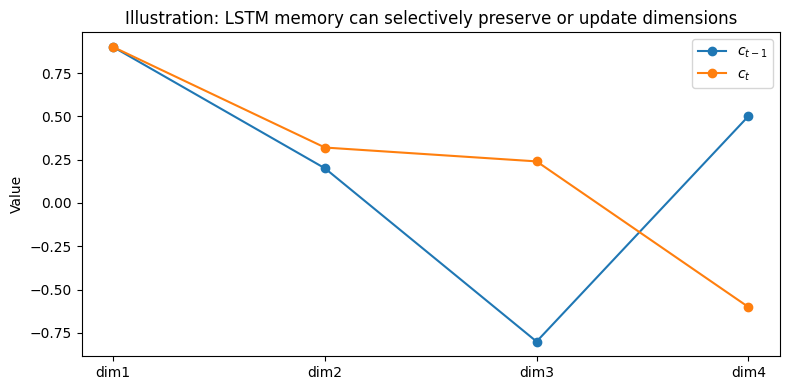

In [ ]:
import matplotlib.pyplot as plt

labels = ["dim1", "dim2", "dim3", "dim4"]

plt.figure(figsize=(8, 4))
plt.plot(labels, c_prev_demo.flatten(), marker='o', label=r"$c_{t-1}$")
plt.plot(labels, c_new_demo.flatten(), marker='o', label=r"$c_t$")
plt.title("Illustration: LSTM memory can selectively preserve or update dimensions")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()

### Concept Check

1. Why is one hidden state not enough for robust long-term memory?

2. What is the role of the cell state $c_t$?

3. What does the forget gate $f_t$ control?

4. What is the difference between:
   - $i_t$
   - $\tilde{c}_t$

5. Write the LSTM cell update equation.

6. Why is the cell update called an additive memory path?

7. What does the output gate $o_t$ do?

8. In one line, how is $h_t$ different from $c_t$?

9. Why does LSTM usually handle long dependencies better than vanilla RNN?

LSTM gives us a powerful gated memory mechanism,
but it also increases architectural complexity.

This raises an important practical question:

> Can we simplify gated recurrence while still keeping the main memory advantages?

That motivates the **GRU**.

# Section 4: GRU as a Simpler Gated Recurrent Model

LSTM improved vanilla RNN by introducing controlled memory flow.

But LSTM has:

- multiple gates
- two states: $c_t$ and $h_t$
- more parameters
- more computation

This leads to a natural question:

> Can we keep the main idea of gated memory, but simplify the architecture?

That is the motivation for the **GRU**: Gated Recurrent Unit.

## Main idea of GRU

GRU keeps the important idea of **gating** but removes the separate cell state.

So unlike LSTM:

- there is no separate $c_t$
- the hidden state itself carries memory

GRU tries to balance:

- expressive sequential memory
- lower architectural complexity
- faster training in some settings

## GRU components

A standard GRU uses:

- **update gate**: $z_t$
- **reset gate**: $r_t$
- **candidate hidden state**: $\tilde{h}_t$
- **final hidden state**: $h_t$

So the GRU still decides:

- how much past information to keep
- how much new information to write

but it does so with fewer moving parts than LSTM.

## Step 1: Update gate

The update gate controls how much of the previous hidden state should be retained.

$$
z_t = \sigma(W_z x_t + U_z h_{t-1} + b_z)
$$

Interpretation:

- if $z_t$ is close to $1$, keep more old information
- if $z_t$ is close to $0$, allow stronger update from new information

This gate plays a role somewhat similar to combined memory retention and update control.

## Step 2: Reset gate

The reset gate controls how strongly the previous hidden state should influence the candidate state.

$$
r_t = \sigma(W_r x_t + U_r h_{t-1} + b_r)
$$

Interpretation:

- if $r_t$ is close to $0$, ignore much of the past while forming the candidate
- if $r_t$ is close to $1$, use the past more strongly

So the reset gate helps decide:

> How much past information should be used while constructing the new proposal?

## Step 3: Candidate hidden state

The GRU proposes a new hidden content:

$$
\tilde{h}_t = \tanh(W_h x_t + U_h (r_t \odot h_{t-1}) + b_h)
$$

Notice the difference from vanilla RNN:

- the previous hidden state is filtered first by $r_t$
- then used to form the candidate state

This means the model can selectively suppress old information while computing the new proposal.

## Step 4: Final hidden state update

The final hidden state is a gated interpolation between old state and candidate state:

$$
h_t = z_t \odot h_{t-1} + (1 - z_t) \odot \tilde{h}_t
$$

This is the key GRU update equation.

Interpretation:

- first term keeps old memory
- second term writes new information

So GRU also has an additive-style update path,
which helps information and gradients flow more stably than vanilla RNN.

## Full GRU equations together

The standard GRU equations are:

$$
z_t = \sigma(W_z x_t + U_z h_{t-1} + b_z)
$$

$$
r_t = \sigma(W_r x_t + U_r h_{t-1} + b_r)
$$

$$
\tilde{h}_t = \tanh(W_h x_t + U_h (r_t \odot h_{t-1}) + b_h)
$$

$$
h_t = z_t \odot h_{t-1} + (1 - z_t) \odot \tilde{h}_t
$$

## How GRU relates to LSTM

### LSTM
- has separate memory state $c_t$
- has hidden state $h_t$
- uses forget, input, and output gates
- more explicit memory control

### GRU
- uses only one state: $h_t$
- has update and reset gates
- fewer parameters
- simpler computation

So GRU can be seen as a more compact gated recurrent design.

## Why GRU can still handle long dependencies better than vanilla RNN

The final GRU update is:

$$
h_t = z_t \odot h_{t-1} + (1 - z_t) \odot \tilde{h}_t
$$

This contains a direct gated path from $h_{t-1}$ to $h_t$.

So, similar to LSTM:

- memory is not fully overwritten at every step
- gradient flow is improved relative to vanilla RNN
- the model can preserve information more selectively

## RNN vs LSTM vs GRU

### Vanilla RNN
- simplest recurrence
- one hidden state
- easiest to write mathematically
- struggles on long dependencies

### LSTM
- strongest explicit memory control
- separate cell state and hidden state
- more parameters and more gates
- widely used when long memory matters

### GRU
- simpler than LSTM
- usually faster and lighter
- often performs competitively
- good practical compromise

## Which one should we use?

There is no universal winner.

In practice:

- **vanilla RNN** is mostly pedagogical or used in limited/simple settings
- **LSTM** is preferred when explicit long-term memory modeling is important
- **GRU** is often used when we want a simpler recurrent model with good performance

The right choice depends on:

- sequence length
- dataset size
- computational budget
- task complexity

## Important limitation

Even though LSTM and GRU improve memory handling,
they still process sequences step by step.

So recurrence still has limitations:

- reduced parallelism
- difficulty with very long contexts
- fixed hidden-size bottleneck
- information must still pass through time rather than being accessed directly

This will matter later when we move beyond recurrence.

In [ ]:
import numpy as np

np.random.seed(7)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

input_dim = 3
hidden_dim = 4

x_t = np.random.randn(input_dim, 1)
h_prev = np.random.randn(hidden_dim, 1)

W_z = np.random.randn(hidden_dim, input_dim)
U_z = np.random.randn(hidden_dim, hidden_dim)
b_z = np.random.randn(hidden_dim, 1)

W_r = np.random.randn(hidden_dim, input_dim)
U_r = np.random.randn(hidden_dim, hidden_dim)
b_r = np.random.randn(hidden_dim, 1)

W_h = np.random.randn(hidden_dim, input_dim)
U_h = np.random.randn(hidden_dim, hidden_dim)
b_h = np.random.randn(hidden_dim, 1)

z_t = sigmoid(W_z @ x_t + U_z @ h_prev + b_z)
r_t = sigmoid(W_r @ x_t + U_r @ h_prev + b_r)
h_t_candidate = np.tanh(W_h @ x_t + U_h @ (r_t * h_prev) + b_h)
h_t = z_t * h_prev + (1 - z_t) * h_t_candidate

print("x_t shape:", x_t.shape)
print("h_prev shape:", h_prev.shape)
print("z_t shape:", z_t.shape)
print("r_t shape:", r_t.shape)
print("candidate h~_t shape:", h_t_candidate.shape)
print("h_t shape:", h_t.shape)

x_t shape: (3, 1)
h_prev shape: (4, 1)
z_t shape: (4, 1)
r_t shape: (4, 1)
candidate h~_t shape: (4, 1)
h_t shape: (4, 1)


In [ ]:
print("Update gate z_t:\n", np.round(z_t, 3))
print("\nReset gate r_t:\n", np.round(r_t, 3))
print("\nCandidate hidden state h~_t:\n", np.round(h_t_candidate, 3))
print("\nFinal hidden state h_t:\n", np.round(h_t, 3))

Update gate z_t:
 [[0.002]
 [0.213]
 [0.337]
 [0.988]]

Reset gate r_t:
 [[0.121]
 [0.877]
 [0.028]
 [0.963]]

Candidate hidden state h~_t:
 [[-0.698]
 [ 0.66 ]
 [ 0.934]
 [-0.438]]

Final hidden state h_t:
 [[-0.695]
 [ 0.351]
 [ 0.62 ]
 [-0.006]]


In [ ]:
# Interpretation demo: how update gate mixes old and new information

h_prev_demo = np.array([[0.9], [0.2], [-0.7], [0.5]])
z_demo = np.array([[0.95], [0.70], [0.20], [0.05]])
h_candidate_demo = np.array([[0.1], [0.8], [0.4], [-0.6]])

h_new_demo = z_demo * h_prev_demo + (1 - z_demo) * h_candidate_demo

print("Previous hidden state h_(t-1):\n", h_prev_demo)
print("\nUpdate gate z_t:\n", z_demo)
print("\nCandidate hidden state h~_t:\n", h_candidate_demo)
print("\nNew hidden state h_t:\n", h_new_demo)

Previous hidden state h_(t-1):
 [[ 0.9]
 [ 0.2]
 [-0.7]
 [ 0.5]]

Update gate z_t:
 [[0.95]
 [0.7 ]
 [0.2 ]
 [0.05]]

Candidate hidden state h~_t:
 [[ 0.1]
 [ 0.8]
 [ 0.4]
 [-0.6]]

New hidden state h_t:
 [[ 0.86 ]
 [ 0.38 ]
 [ 0.18 ]
 [-0.545]]


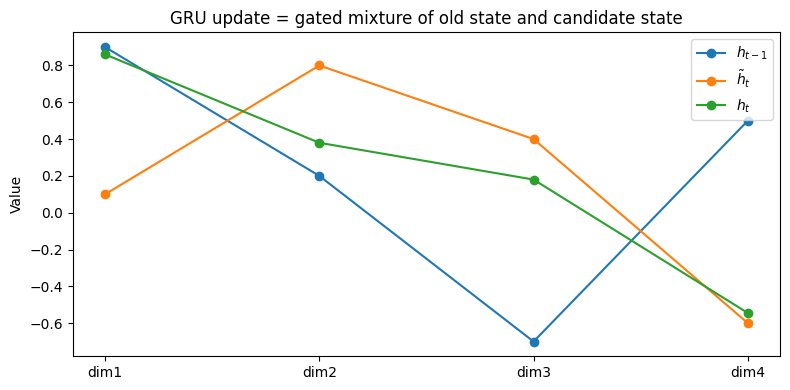

In [ ]:
import matplotlib.pyplot as plt

labels = ["dim1", "dim2", "dim3", "dim4"]

plt.figure(figsize=(8, 4))
plt.plot(labels, h_prev_demo.flatten(), marker='o', label=r"$h_{t-1}$")
plt.plot(labels, h_candidate_demo.flatten(), marker='o', label=r"$\tilde{h}_t$")
plt.plot(labels, h_new_demo.flatten(), marker='o', label=r"$h_t$")
plt.title("GRU update = gated mixture of old state and candidate state")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()

### Concept Check

1. Why was GRU introduced after LSTM?

2. What is the main structural difference between LSTM and GRU?

3. What does the update gate $z_t$ control?

4. What does the reset gate $r_t$ control?

5. Write the GRU hidden state update equation.

6. Why is the GRU update considered more stable than vanilla RNN?

7. In practice, when might GRU be preferred over LSTM?

8. Does GRU completely solve all limitations of recurrence?

We now understand the theory side:

- vanilla RNN has fragile memory
- LSTM introduces controlled long-term memory
- GRU offers a simpler gated alternative

The next step is to make this concrete.

So now we move from equations to implementation by building a
**character-level LSTM text generator** from scratch in PyTorch.

# Section 5: Building a Character-Level LSTM Text Generator

Now we move from theory to practice.

Our goal is to train an LSTM to do:

> Given a sequence of characters, predict the next character.

This is one of the simplest sequence generation tasks and is ideal for understanding:

- sequential input processing
- hidden memory in LSTM
- next-step prediction
- autoregressive generation

## Why character-level modeling?

We choose **characters** instead of words because:

- vocabulary is very small
- preprocessing is simple
- training is fast
- next-step behavior becomes very visible

The tradeoff is that the model must learn language structure from smaller units.

So character-level modeling is not the most powerful approach,
but it is excellent for learning sequence generation.

## Next-character prediction setup

Suppose the text is:

`hello world`

If input sequence length is $5$, one training example may look like:

- input: `hello`
- target: `ello `

Notice the alignment:

at each time step, the model sees one character and must predict the next character.

So if input indices are:

$$
[x_1, x_2, x_3, x_4, x_5]
$$

then targets are:

$$
[x_2, x_3, x_4, x_5, x_6]
$$

This is a sequence-to-sequence prediction problem.

## Small corpus for classroom training

We will use a tiny repeated corpus so that training runs quickly in class.

This is not meant to build a production text generator.

It is meant to reveal the full pipeline clearly:

text $\rightarrow$ integer encoding $\rightarrow$ sequence pairs $\rightarrow$ LSTM training $\rightarrow$ generation

## Vocabulary mapping

At character level, the vocabulary is the set of unique characters in the corpus.

If the corpus contains characters like:

$$
\{a, b, c, \dots, \text{space}, \text{punctuation}\}
$$

we map them to integer ids:

$$
\text{char} \rightarrow \text{index}
$$

and also create the reverse map:

$$
\text{index} \rightarrow \text{char}
$$

This lets the model work numerically while we interpret outputs as text.

## Tensor shape roadmap

We must keep tensor shapes clear.

If:

- batch size = $B$
- sequence length = $T$
- embedding dimension = $E$
- hidden size = $H$
- vocabulary size = $V$

then the shape flow is:

1. input indices:
$$
(B, T)
$$

2. embedding output:
$$
(B, T, E)
$$

3. LSTM output:
$$
(B, T, H)
$$

4. linear layer output (logits):
$$
(B, T, V)
$$

5. after flattening for loss:
$$
(BT, V)
$$

and targets become:

$$
(BT)
$$

## Model architecture

We will use:

- **Embedding layer**: converts character ids into dense vectors
- **LSTM layer**: processes sequence over time
- **Linear layer**: maps hidden state to vocabulary logits

So the model computes:

$$
x_t \rightarrow e_t \rightarrow \text{LSTM} \rightarrow h_t \rightarrow \text{Linear} \rightarrow \text{logits over characters}
$$

At each time step, the model predicts the next character distribution.

## Loss function

For next-character prediction, this is a multiclass classification task at every time step.

So we use **cross-entropy loss** between:

- predicted logits for each position
- true next character index for each position

The model is not directly predicting a full sentence.
It is learning one next step at a time.

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Small classroom corpus
text = """
deep learning is powerful.
lstm can remember patterns.
gru is simpler than lstm.
sequence models process ordered data.
deep learning is powerful.
lstm can remember patterns.
gru is simpler than lstm.
sequence models process ordered data.
""".lower()

print(text[:300])
print("\nCorpus length:", len(text))


deep learning is powerful.
lstm can remember patterns.
gru is simpler than lstm.
sequence models process ordered data.
deep learning is powerful.
lstm can remember patterns.
gru is simpler than lstm.
sequence models process ordered data.


Corpus length: 239


In [ ]:
# Build vocabulary
chars = sorted(list(set(text)))
vocab_size = len(chars)

char2idx = {ch: i for i, ch in enumerate(chars)}
idx2char = {i: ch for ch, i in char2idx.items()}

print("Unique characters:", chars)
print("Vocabulary size:", vocab_size)
print("\nCharacter to index mapping:")
print(char2idx)

Unique characters: ['\n', ' ', '.', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'w']
Vocabulary size: 23

Character to index mapping:
{'\n': 0, ' ': 1, '.': 2, 'a': 3, 'b': 4, 'c': 5, 'd': 6, 'e': 7, 'f': 8, 'g': 9, 'h': 10, 'i': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'w': 22}


In [ ]:
# Encode full text into integer ids
encoded = np.array([char2idx[ch] for ch in text], dtype=np.int64)

print("First 100 encoded tokens:")
print(encoded[:100])
print("Encoded shape:", encoded.shape)

First 100 encoded tokens:
[ 0  6  7  7 16  1 12  7  3 18 14 11 14  9  1 11 19  1 16 15 22  7 18  8
 21 12  2  0 12 19 20 13  1  5  3 14  1 18  7 13  7 13  4  7 18  1 16  3
 20 20  7 18 14 19  2  0  9 18 21  1 11 19  1 19 11 13 16 12  7 18  1 20
 10  3 14  1 12 19 20 13  2  0 19  7 17 21  7 14  5  7  1 13 15  6  7 12
 19  1 16 18]
Encoded shape: (239,)


In [ ]:
# Build sequence pairs
seq_len = 20

inputs = []
targets = []

for i in range(len(encoded) - seq_len):
    x_seq = encoded[i:i+seq_len]
    y_seq = encoded[i+1:i+seq_len+1]
    inputs.append(x_seq)
    targets.append(y_seq)

inputs = np.array(inputs)
targets = np.array(targets)

print("inputs shape:", inputs.shape)
print("targets shape:", targets.shape)

sample_i = 0
print("\nSample input indices:\n", inputs[sample_i])
print("Sample target indices:\n", targets[sample_i])

print("\nDecoded input :", ''.join(idx2char[idx] for idx in inputs[sample_i]))
print("Decoded target:", ''.join(idx2char[idx] for idx in targets[sample_i]))

inputs shape: (219, 20)
targets shape: (219, 20)

Sample input indices:
 [ 0  6  7  7 16  1 12  7  3 18 14 11 14  9  1 11 19  1 16 15]
Sample target indices:
 [ 6  7  7 16  1 12  7  3 18 14 11 14  9  1 11 19  1 16 15 22]

Decoded input : 
deep learning is po
Decoded target: deep learning is pow


In [ ]:
# Convert to torch tensors
X = torch.tensor(inputs, dtype=torch.long)
Y = torch.tensor(targets, dtype=torch.long)

print("X shape:", X.shape)   # (num_samples, seq_len)
print("Y shape:", Y.shape)   # (num_samples, seq_len)

X shape: torch.Size([219, 20])
Y shape: torch.Size([219, 20])


In [ ]:
class CharLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        # x: (B, T)
        x = self.embedding(x)          # (B, T, E)
        out, hidden = self.lstm(x, hidden)   # out: (B, T, H)
        logits = self.fc(out)          # (B, T, V)
        return logits, hidden

In [ ]:
# Hyperparameters
embed_dim = 16
hidden_dim = 16
learning_rate = 0.009
epochs = 50
batch_size = 4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = CharLSTM(vocab_size, embed_dim, hidden_dim).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

print(model)

Using device: cuda
CharLSTM(
  (embedding): Embedding(23, 16)
  (lstm): LSTM(16, 16, batch_first=True)
  (fc): Linear(in_features=16, out_features=23, bias=True)
)


In [ ]:
# Simple mini-batch training loop
num_samples = X.shape[0]
loss_history = []

for epoch in range(epochs):
    permutation = torch.randperm(num_samples)
    epoch_loss = 0.0

    for i in range(0, num_samples, batch_size):
        indices = permutation[i:i+batch_size]
        xb = X[indices].to(device)   # (B, T)
        yb = Y[indices].to(device)   # (B, T)

        optimizer.zero_grad()

        logits, _ = model(xb)        # (B, T, V)

        B, T, V = logits.shape
        loss = criterion(logits.reshape(B * T, V), yb.reshape(B * T))

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / (num_samples / batch_size)
    loss_history.append(avg_loss)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{epochs}] - Loss: {avg_loss:.4f}")

Epoch [1/50] - Loss: 2.4526
Epoch [10/50] - Loss: 0.1756
Epoch [20/50] - Loss: 0.1310
Epoch [30/50] - Loss: 0.1195
Epoch [40/50] - Loss: 0.1156
Epoch [50/50] - Loss: 0.1109


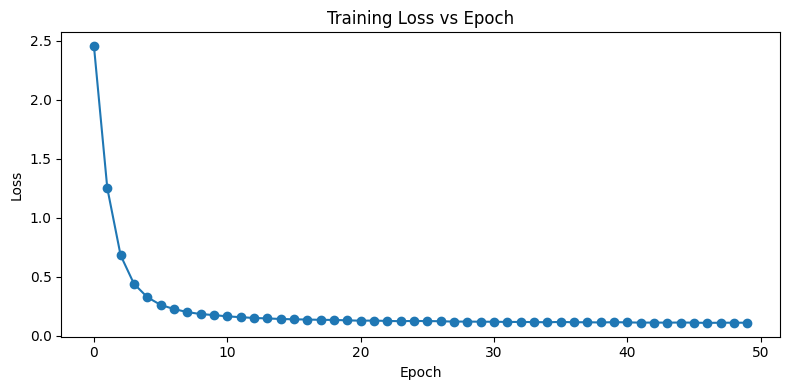

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(loss_history, marker='o')
plt.title("Training Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()

In [ ]:
# Inspect one forward pass with explicit shapes
xb = X[:4].to(device)   # batch size 4
logits, hidden = model(xb)

print("Input batch shape:", xb.shape)
print("Logits shape:", logits.shape)

h_n, c_n = hidden
print("Final hidden state h_n shape:", h_n.shape)
print("Final cell state c_n shape:", c_n.shape)

Input batch shape: torch.Size([4, 20])
Logits shape: torch.Size([4, 20, 23])
Final hidden state h_n shape: torch.Size([1, 4, 16])
Final cell state c_n shape: torch.Size([1, 4, 16])


In [ ]:
# Decode one sample and show model's argmax prediction at each position

model.eval()
with torch.no_grad():
    xb = X[:1].to(device)
    logits, _ = model(xb)
    preds = torch.argmax(logits, dim=-1).squeeze(0).cpu().numpy()

input_text = ''.join(idx2char[idx] for idx in X[0].numpy())
target_text = ''.join(idx2char[idx] for idx in Y[0].numpy())
pred_text = ''.join(idx2char[idx] for idx in preds)

print("Input : ", repr(input_text))
print("Target: ", repr(target_text))
print("Pred  : ", repr(pred_text))
model.train()

Input :  '\ndeep learning is po'
Target:  'deep learning is pow'
Pred  :  'geep learning is pow'


CharLSTM(
  (embedding): Embedding(23, 16)
  (lstm): LSTM(16, 16, batch_first=True)
  (fc): Linear(in_features=16, out_features=23, bias=True)
)

In [ ]:
model.eval()
with torch.no_grad():
    xb = X[:1].to(device)
    logits, _ = model(xb)
    preds = torch.argmax(logits, dim=-1).squeeze(0).cpu().numpy()

input_ids = X[0].numpy()
target_ids = Y[0].numpy()

print("Position-wise comparison:\n")
print(f"{'pos':<5}{'input':<10}{'target(next)':<15}{'pred(next)':<15}")
print("-" * 45)

for i, (inp, tgt, pred) in enumerate(zip(input_ids, target_ids, preds)):
    print(f"{i:<5}{repr(idx2char[inp]):<10}{repr(idx2char[tgt]):<15}{repr(idx2char[pred]):<15}")

#model.train()

Position-wise comparison:

pos  input     target(next)   pred(next)     
---------------------------------------------
0    '\n'      'd'            'g'            
1    'd'       'e'            'e'            
2    'e'       'e'            'e'            
3    'e'       'p'            'p'            
4    'p'       ' '            ' '            
5    ' '       'l'            'l'            
6    'l'       'e'            'e'            
7    'e'       'a'            'a'            
8    'a'       'r'            'r'            
9    'r'       'n'            'n'            
10   'n'       'i'            'i'            
11   'i'       'n'            'n'            
12   'n'       'g'            'g'            
13   'g'       ' '            ' '            
14   ' '       'i'            'i'            
15   'i'       's'            's'            
16   's'       ' '            ' '            
17   ' '       'p'            'p'            
18   'p'       'o'            'o'            
19   'o

In [ ]:
sample_idx = 50

model.eval()
with torch.no_grad():
    xb = X[sample_idx:sample_idx+1].to(device)
    logits, _ = model(xb)
    preds = torch.argmax(logits, dim=-1).squeeze(0).cpu().numpy()

input_text = ''.join(idx2char[idx] for idx in X[sample_idx].numpy())
target_text = ''.join(idx2char[idx] for idx in Y[sample_idx].numpy())
pred_text = ''.join(idx2char[idx] for idx in preds)

print("Input : ", repr(input_text))
print("Target: ", repr(target_text))
print("Pred  : ", repr(pred_text))

#model.train()

Input :  'erns.\ngru is simpler'
Target:  'rns.\ngru is simpler '
Pred  :  'r s.\ngru is simpler '


In [ ]:
model.eval()
with torch.no_grad():
    xb = X[:1].to(device)
    logits, _ = model(xb)
    preds = torch.argmax(logits, dim=-1).squeeze(0).cpu().numpy()

input_ids = X[0].numpy()
target_ids = Y[0].numpy()

print(f"{'pos':<5}{'inp':<8}{'target':<10}{'pred':<10}{'correct'}")
print("-" * 45)

for i, (inp, tgt, pred) in enumerate(zip(input_ids, target_ids, preds)):
    correct = tgt == pred
    print(f"{i:<5}{repr(idx2char[inp]):<8}{repr(idx2char[tgt]):<10}{repr(idx2char[pred]):<10}{correct}")

#model.train()

pos  inp     target    pred      correct
---------------------------------------------
0    '\n'    'd'       'g'       False
1    'd'     'e'       'e'       True
2    'e'     'e'       'e'       True
3    'e'     'p'       'p'       True
4    'p'     ' '       ' '       True
5    ' '     'l'       'l'       True
6    'l'     'e'       'e'       True
7    'e'     'a'       'a'       True
8    'a'     'r'       'r'       True
9    'r'     'n'       'n'       True
10   'n'     'i'       'i'       True
11   'i'     'n'       'n'       True
12   'n'     'g'       'g'       True
13   'g'     ' '       ' '       True
14   ' '     'i'       'i'       True
15   'i'     's'       's'       True
16   's'     ' '       ' '       True
17   ' '     'p'       'p'       True
18   'p'     'o'       'o'       True
19   'o'     'w'       'w'       True


In [ ]:
model.eval()
with torch.no_grad():
    xb = X[:1].to(device)
    logits, _ = model(xb)
    probs = torch.softmax(logits, dim=-1)

input_ids = X[0].numpy()
target_ids = Y[0].numpy()

for t in range(5):  # first 5 positions only
    top_probs, top_idxs = torch.topk(probs[0, t], k=3)

    print(f"\nPosition {t}")
    print("Input char :", repr(idx2char[input_ids[t]]))
    print("Target char:", repr(idx2char[target_ids[t]]))
    print("Top-3 predictions:")

    for p, idx in zip(top_probs.cpu().numpy(), top_idxs.cpu().numpy()):
        print(f"   {repr(idx2char[idx])} : {p:.4f}")

#model.train()


Position 0
Input char : '\n'
Target char: 'd'
Top-3 predictions:
   'g' : 0.3364
   'l' : 0.2491
   's' : 0.1881

Position 1
Input char : 'd'
Target char: 'e'
Top-3 predictions:
   'e' : 0.9998
   ' ' : 0.0001
   's' : 0.0000

Position 2
Input char : 'e'
Target char: 'e'
Top-3 predictions:
   'e' : 0.9894
   'n' : 0.0068
   'q' : 0.0009

Position 3
Input char : 'e'
Target char: 'p'
Top-3 predictions:
   'p' : 0.9904
   ' ' : 0.0044
   'l' : 0.0019

Position 4
Input char : 'p'
Target char: ' '
Top-3 predictions:
   ' ' : 0.9974
   'l' : 0.0015
   'e' : 0.0004


In [ ]:
model.eval()
with torch.no_grad():
    sample_idx = 25
    xb = X[sample_idx:sample_idx+1].to(device)
    logits, _ = model(xb)
    preds = torch.argmax(logits, dim=-1).squeeze(0).cpu().numpy()

input_ids = X[sample_idx].numpy()
target_ids = Y[sample_idx].numpy()

print("Decoded sequence comparison:\n")
print("Input : ", repr(''.join(idx2char[i] for i in input_ids)))
print("Target: ", repr(''.join(idx2char[i] for i in target_ids)))
print("Pred  : ", repr(''.join(idx2char[i] for i in preds)))

print("\nPosition-wise comparison:\n")
print(f"{'pos':<5}{'input':<10}{'target(next)':<15}{'pred(next)':<15}{'correct'}")
print("-" * 60)

for i, (inp, tgt, pred) in enumerate(zip(input_ids, target_ids, preds)):
    print(f"{i:<5}{repr(idx2char[inp]):<10}{repr(idx2char[tgt]):<15}{repr(idx2char[pred]):<15}{tgt == pred}")

#model.train()

Decoded sequence comparison:

Input :  'l.\nlstm can remember'
Target:  '.\nlstm can remember '
Pred  :  's\nlstm can remember '

Position-wise comparison:

pos  input     target(next)   pred(next)     correct
------------------------------------------------------------
0    'l'       '.'            's'            False
1    '.'       '\n'           '\n'           True
2    '\n'      'l'            'l'            True
3    'l'       's'            's'            True
4    's'       't'            't'            True
5    't'       'm'            'm'            True
6    'm'       ' '            ' '            True
7    ' '       'c'            'c'            True
8    'c'       'a'            'a'            True
9    'a'       'n'            'n'            True
10   'n'       ' '            ' '            True
11   ' '       'r'            'r'            True
12   'r'       'e'            'e'            True
13   'e'       'm'            'm'            True
14   'm'       'e'          

### Concept Check

1. Why is next-character prediction a sequence learning problem?

2. If the input sequence is `hello`, what is the aligned target sequence?

3. Why do we need a character-to-index mapping?

4. What is the role of the embedding layer?

5. If input tensor shape is $(B, T)$, what is the shape after embedding?

6. What is the shape of the LSTM output tensor?

7. Why do we flatten logits and targets before cross-entropy loss?

8. Does the model predict the whole sentence at once, or one next step at each position?

9. What kinds of patterns can a small character-level LSTM learn from a tiny corpus?

We have now trained an LSTM to predict the next character.

But prediction logits are not yet text.

To generate text, we must convert logits into probabilities, sample the next character, feed it back into the model, and repeat.

This leads to an important generation concept:

**temperature sampling**.

# Section 6: Temperature Sampling

Our trained model outputs **logits**, not characters directly.

At each time step, the model produces a score vector over the vocabulary:

$$
z = [z_1, z_2, \dots, z_V]
$$

where $V$ is the vocabulary size.

These scores must be converted into probabilities before we sample the next character.

## From logits to probabilities

We convert logits into probabilities using the softmax function:

$$
p_i = \frac{e^{z_i}}{\sum_{j=1}^{V} e^{z_j}}
$$

This gives a valid probability distribution:

- each probability is nonnegative
- probabilities sum to $1$

Then we can sample one character according to these probabilities.

## Why not always choose the largest probability?

One simple strategy is **greedy decoding**:

$$
\hat{i} = \arg\max_i p_i
$$

This always picks the most probable next character.

That sounds reasonable, but in generation it often causes problems:

- output becomes repetitive
- diversity is low
- model can get stuck in safe patterns

So instead of always taking the maximum, we often **sample** from the distribution.

## Temperature scaling

Before applying softmax, we can divide logits by a temperature value $\tau > 0$:

$$
p_i(\tau) = \frac{e^{z_i / \tau}}{\sum_{j=1}^{V} e^{z_j / \tau}}
$$

This is called **temperature sampling**.

## Interpretation of temperature

### Low temperature: $\tau < 1$
Dividing by a small number makes logit differences larger.

So the distribution becomes sharper:

- highest-probability characters dominate
- generation becomes more deterministic
- output is safer but less diverse

### High temperature: $\tau > 1$
Dividing by a larger number compresses logit differences.

So the distribution becomes flatter:

- lower-probability characters get more chance
- generation becomes more diverse
- output may become noisy or incoherent

## Extreme cases

As temperature becomes very small:

$$
\tau \to 0
$$

the distribution approaches a near one-hot preference on the most likely character.

As temperature becomes very large:

$$
\tau \to \infty
$$

the distribution becomes closer to uniform.

So temperature controls the tradeoff between:

- **certainty**
- **diversity**

## Generation process

To generate text, we repeat this loop:

1. feed current sequence into the model
2. take logits for the last time step
3. apply temperature-scaled softmax
4. sample the next character
5. append it to the sequence
6. feed the updated sequence back again

This is an **autoregressive** process:
each new prediction becomes part of the future input.

## Important note

Temperature does **not** retrain the model.

It only changes how we convert model scores into sampling probabilities at generation time.

So:

- training stays the same
- decoding behavior changes

In [ ]:
# A tiny illustration of temperature on a fixed logits vector
import torch.nn.functional as F
logits_example = torch.tensor([2.5, 1.2, 0.5, -0.3])

for temp in [0.5, 1.0, 1.5, 2.0]:
    probs = F.softmax(logits_example / temp, dim=0)
    print(f"Temperature = {temp}")
    print(np.round(probs.numpy(), 4))
    print("Sum =", probs.sum().item())
    print()

Temperature = 0.5
[0.9122 0.0678 0.0167 0.0034]
Sum = 0.9999999403953552

Temperature = 1.0
[0.6809 0.1856 0.0921 0.0414]
Sum = 1.0

Temperature = 1.5
[0.5439 0.2286 0.1434 0.0841]
Sum = 0.9999999403953552

Temperature = 2.0
[0.4681 0.2443 0.1722 0.1154]
Sum = 1.0



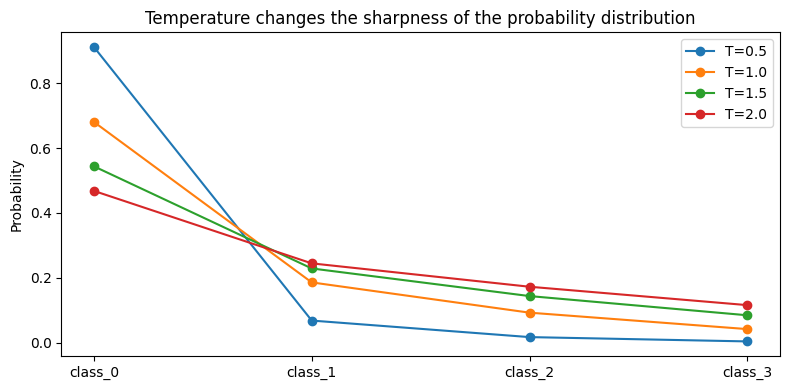

In [ ]:
# Visualize how temperature changes a probability distribution

temps = [0.5, 1.0, 1.5, 2.0]
all_probs = [F.softmax(logits_example / t, dim=0).numpy() for t in temps]

x = np.arange(len(logits_example))

plt.figure(figsize=(8, 4))
for i, probs in enumerate(all_probs):
    plt.plot(x, probs, marker='o', label=f"T={temps[i]}")
plt.xticks(x, [f"class_{i}" for i in range(len(logits_example))])
plt.title("Temperature changes the sharpness of the probability distribution")
plt.ylabel("Probability")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
def generate_text(model, start_text, char2idx, idx2char, length=100, temperature=1.0, device='cpu'):
    model.eval()

    generated = start_text

    # Start from the provided seed text
    input_ids = torch.tensor([[char2idx[ch] for ch in start_text]], dtype=torch.long).to(device)

    hidden = None

    with torch.no_grad():
        # Warm up the model using the seed text
        logits, hidden = model(input_ids, hidden)

        current_input = input_ids[:, -1:]  # last character only

        for _ in range(length):
            logits, hidden = model(current_input, hidden)   # logits: (1, 1, V)
            last_logits = logits[:, -1, :].squeeze(0)       # (V,)

            scaled_logits = last_logits / temperature
            probs = F.softmax(scaled_logits, dim=0)

            next_idx = torch.multinomial(probs, num_samples=1).item()
            next_char = idx2char[next_idx]

            generated += next_char

            current_input = torch.tensor([[next_idx]], dtype=torch.long).to(device)

    model.train()
    return generated

In [ ]:
# Generate text using multiple temperature values

seed_text = "deep "
print("Seed text:", repr(seed_text))

for temp in [0.5, 0.7, 1.0, 1.5]:
    generated = generate_text(
        model=model,
        start_text=seed_text,
        char2idx=char2idx,
        idx2char=idx2char,
        length=100,
        temperature=temp,
        device=device
    )
    print(f"\n--- Temperature = {temp} ---")
    print(generated)

Seed text: 'deep '

--- Temperature = 0.5 ---
deep learning is powerful.
lstm can remember patterns.
gru is simpler than lstm.
sequence models process 

--- Temperature = 0.7 ---
deep learning is powerful.
lstm can remember patterns.
gru is simpler than lstm.
sequence models process 

--- Temperature = 1.0 ---
deep can remember patterns.
gru is simpler than lstm.
sequence models process ordered data.
deep learning

--- Temperature = 1.5 ---
deep learning is powerful.
lstm can remember pattterns.
gru is simpler than lstm.
sequence models process


In [ ]:
# Compare greedy decoding with stochastic sampling

def generate_text_greedy(model, start_text, char2idx, idx2char, length=100, device='cpu'):
    model.eval()

    generated = start_text
    input_ids = torch.tensor([[char2idx[ch] for ch in start_text]], dtype=torch.long).to(device)
    hidden = None

    with torch.no_grad():
        logits, hidden = model(input_ids, hidden)
        current_input = input_ids[:, -1:]

        for _ in range(length):
            logits, hidden = model(current_input, hidden)
            last_logits = logits[:, -1, :].squeeze(0)
            next_idx = torch.argmax(last_logits).item()
            next_char = idx2char[next_idx]

            generated += next_char
            current_input = torch.tensor([[next_idx]], dtype=torch.long).to(device)

    model.train()
    return generated

print("--- Greedy decoding ---")
print(generate_text_greedy(model, "deep ", char2idx, idx2char, length=100, device=device))

--- Greedy decoding ---
deep learning is powerful.
lstm can remember patterns.
gru is simpler than lstm.
sequence models process 


### Concept Check

1. What does the model output at each time step: characters or logits?

2. Why do we apply softmax to logits?

3. What is greedy decoding?

4. Why can greedy decoding produce repetitive text?

5. Write the temperature-scaled softmax formula.

6. What happens to the probability distribution when temperature is very low?

7. What happens when temperature is very high?

8. Does temperature affect training, inference, or both?

9. In one line, what does temperature control during generation?

We have now completed the full recurrent generation loop:

- sequence modeling motivation
- RNN limitation
- LSTM solution
- GRU simplification
- character-level LSTM training
- temperature-based text generation

The final step is to consolidate the big picture:

What did LSTM solve, what does GRU simplify, and why do we still eventually move beyond recurrence?

# Section 7: Consolidation

Let us summarize the full story.

We began from the limitation of **TF-IDF-based text modeling**.

TF-IDF gives a useful static representation, but many NLP problems require:

- order sensitivity
- evolving context
- dependence on earlier tokens

That motivated the move from static text vectors to **sequence models**.

## What was the main weakness of vanilla RNN?

Vanilla RNN processes sequences through the recurrence:

$$
h_t = \tanh(W_x x_t + W_h h_{t-1} + b)
$$

This gives a sequential state update, but long-term learning is difficult because:

- information is repeatedly transformed through time
- gradients must also pass through many time steps
- repeated Jacobian multiplication causes vanishing or exploding gradients
- $\tanh$ saturation worsens gradient decay

So vanilla RNN has memory, but it is not a reliable long-range memory.

## What problem does LSTM solve?

LSTM introduces controlled memory through:

- forget gate
- input gate
- candidate memory
- output gate
- separate cell state $c_t$
- hidden state $h_t$

Its most important equation is:

$$
c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t
$$

This additive memory path is the key improvement.

Why?

Because memory is no longer fully overwritten at every step,
and gradients can flow more effectively when the forget gate remains near $1$.

## Where does GRU fit?

GRU keeps the main benefit of gating, but simplifies the architecture.

Instead of separate cell state and hidden state, GRU uses one hidden state with:

- update gate
- reset gate
- candidate hidden state

Its central update is:

$$
h_t = z_t \odot h_{t-1} + (1 - z_t) \odot \tilde{h}_t
$$

So GRU is a lighter gated recurrent model that often performs competitively with LSTM.

## What did our practical model actually learn?

In the character-level LSTM text generator, the model learned:

- local character transitions
- repeated substrings
- spacing and punctuation patterns
- small sequential regularities in the corpus

It was trained as a **next-character predictor**.

So at each time step, it learned:

> given previous characters, what is the probability distribution of the next character?

That is the core predictive idea behind sequence generation.

## What did temperature sampling teach us?

The model outputs logits, and temperature changes how sharply we sample from those logits.

Low temperature:

- safer
- more deterministic
- more repetitive

High temperature:

- more diverse
- more exploratory
- often noisier

So generation quality depends not only on the trained model,
but also on the decoding strategy.

## What are the remaining limitations of recurrent models?

Even after LSTM and GRU, recurrence still has important limitations:

1. **Sequential computation**
   - tokens are processed one step at a time
   - parallelism is limited

2. **Long-range access is still indirect**
   - information from far positions must still pass through intermediate steps

3. **Fixed-size state bottleneck**
   - the model compresses past context into finite hidden representations

4. **Training over very long sequences remains difficult**
   - gated recurrence helps, but does not eliminate all optimization issues

## Why attention becomes the next natural step

At this point, the natural question is:

> Instead of forcing all useful past information to travel step by step through recurrence, can a model look back more directly at relevant parts of the sequence?

This is the key motivation for the next lecture.

So the bridge is:

- RNN introduced sequential state
- LSTM improved long-term memory
- GRU simplified gated recurrence
- but recurrence still struggles with direct access to distant information

That is why the next major idea is **attention**.

## Final takeaway

Today’s lecture gives one complete conceptual arc:

$$
\text{TF-IDF} \rightarrow \text{RNN limitation} \rightarrow \text{LSTM} \rightarrow \text{GRU} \rightarrow \text{text generation} \rightarrow \text{need for something beyond recurrence}
$$

So the most important understanding is not just the formulas.

It is this:

> LSTM and GRU were major improvements in sequence modeling,  
> but they are still part of the recurrent paradigm, and that paradigm has structural limits.

In [ ]:
# Compact conceptual summary in Python dictionary form

summary = {
    "TF-IDF": "Static document representation; ignores sequence order.",
    "Vanilla RNN": "Sequential hidden state, but weak long-range learning due to vanishing/exploding gradients.",
    "LSTM": "Controlled memory with gates and separate cell state.",
    "GRU": "Simplified gated recurrent model without separate cell state.",
    "Char-level LSTM Generator": "Learns next-character prediction and autoregressive generation.",
    "Temperature Sampling": "Controls certainty vs diversity during generation.",
    "Next Step": "Need a better way to access distant information."
}

for key, value in summary.items():
    print(f"{key}: {value}")

TF-IDF: Static document representation; ignores sequence order.
Vanilla RNN: Sequential hidden state, but weak long-range learning due to vanishing/exploding gradients.
LSTM: Controlled memory with gates and separate cell state.
GRU: Simplified gated recurrent model without separate cell state.
Char-level LSTM Generator: Learns next-character prediction and autoregressive generation.
Temperature Sampling: Controls certainty vs diversity during generation.
Next Step: Need a better way to access distant information.


In [ ]:
# Quick side-by-side comparison table using pandas

import pandas as pd

comparison_df = pd.DataFrame({
    "Model": ["Vanilla RNN", "LSTM", "GRU"],
    "Memory Mechanism": [
        "Single hidden state",
        "Cell state + hidden state",
        "Single gated hidden state"
    ],
    "Main Control": [
        "No explicit gates",
        "Forget/Input/Output gates",
        "Update/Reset gates"
    ],
    "Long Dependency Handling": [
        "Weak",
        "Strong relative to RNN",
        "Strong relative to RNN"
    ],
    "Complexity": [
        "Low",
        "High",
        "Medium"
    ]
})

comparison_df

,Model,Memory Mechanism,Main Control,Long Dependency Handling,Complexity
0,Vanilla RNN,Single hidden state,No explicit gates,Weak,Low
1,LSTM,Cell state + hidden state,Forget/Input/Output gates,Strong relative to RNN,High
2,GRU,Single gated hidden state,Update/Reset gates,Strong relative to RNN,Medium
